In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [14]:
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])

In [15]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000
mean,2020.131451,180.121227,23.743477,29.178345,19.272349,9.911230,2.524618,65.627963,2.969421,4.239673,91.747295,12.819402,6.423564
std,3.248591,106.284416,5.356945,5.124934,6.506001,5.516419,4.730845,21.852218,1.170709,1.401461,9.659611,5.008700,3.476707
min,2015.000000,1.000000,10.374350,15.650000,2.405775,0.940000,0.000000,4.690000,0.460000,0.790000,76.360000,1.160000,1.000000
25%,2017.000000,86.000000,19.480000,26.700000,13.530000,4.380000,0.010000,56.210000,2.070000,3.130000,83.630000,9.530000,3.000000
50%,2020.000000,179.000000,25.210000,28.720000,21.960000,10.190000,0.390000,72.610000,2.820000,4.180000,96.310000,12.490000,6.000000
75%,2023.000000,272.000000,27.540000,30.710000,25.240000,14.810000,2.720000,82.530000,3.800000,5.240000,100.720000,17.640000,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,23.240000,27.752097,93.790000,7.284779,8.998091,101.510000,21.740000,12.000000


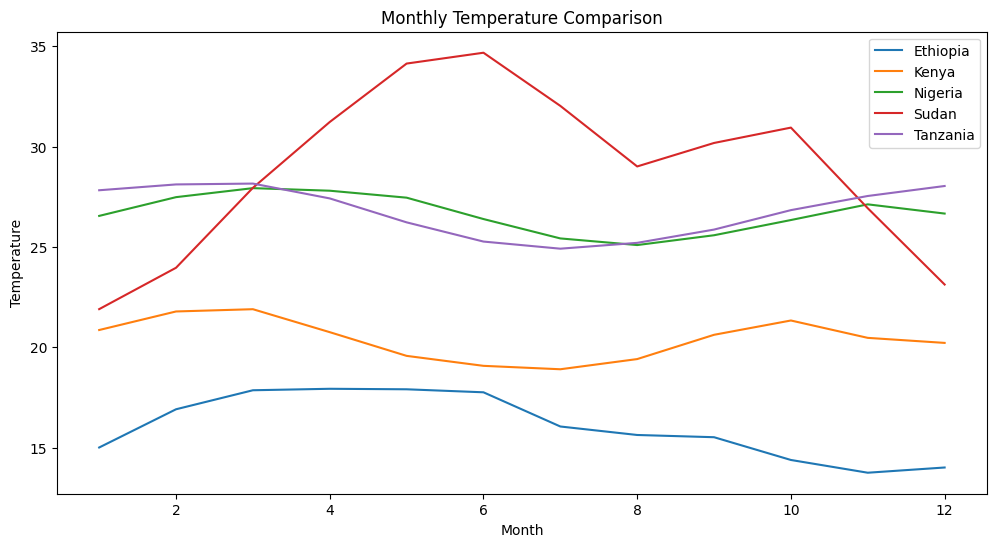

In [16]:
monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(12,6))

for country in monthly_temp["Country"].unique():
    data = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(data["Month"], data["T2M"], label=country)

plt.legend()
plt.title("Monthly Temperature Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

In [17]:
df.groupby("Country")["T2M"].agg(["mean", "median", "std"])

,mean,median,std
Country,,,
Ethiopia,16.068679,16.04,1.897501
Kenya,20.427483,20.36,1.438281
Nigeria,26.659160,26.82,1.115192
Sudan,28.759607,29.16,4.679431
Tanzania,26.802458,26.99,1.325279


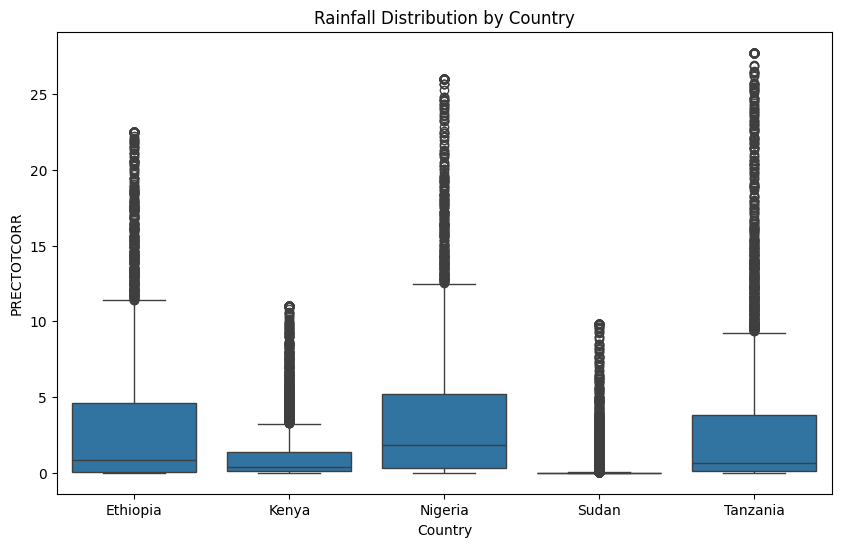

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Rainfall Distribution by Country")
plt.show()

In [19]:
df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])

,mean,median,std
Country,,,
Ethiopia,3.440719,0.82,5.374903
Kenya,1.323742,0.38,2.282832
Nigeria,3.950704,1.84,5.454583
Sudan,0.487103,0.00,1.665770
Tanzania,3.420823,0.64,6.002178


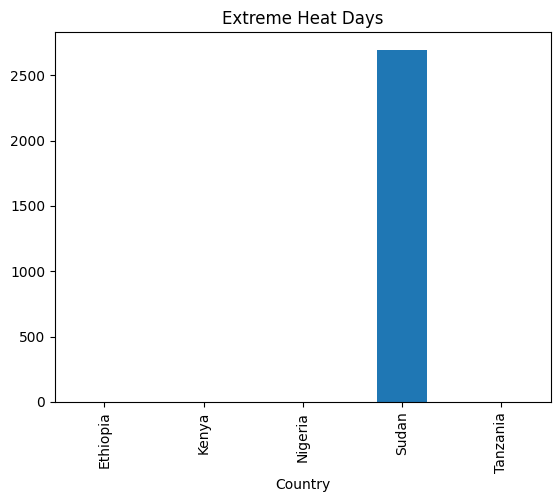

In [20]:
df["Extreme_Heat"] = df["T2M_MAX"] > 35

heat_counts = df.groupby("Country")["Extreme_Heat"].sum()

heat_counts.plot(kind="bar", title="Extreme Heat Days")
plt.show()

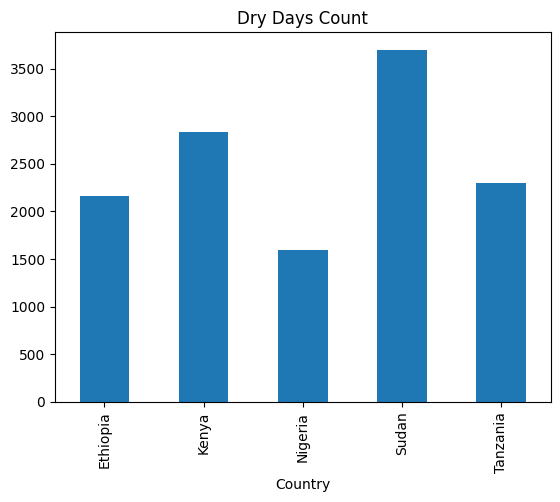

In [21]:
df["Dry_Day"] = df["PRECTOTCORR"] < 1

dry_counts = df.groupby("Country")["Dry_Day"].sum()

dry_counts.plot(kind="bar", title="Dry Days Count")
plt.show()

In [22]:
from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"] for c in df["Country"].unique()]

stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 0.0


In [23]:
ranking = df.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "std",
    "Extreme_Heat": "sum",
    "Dry_Day": "sum"
}).reset_index()

ranking.columns = [
    "Country",
    "Avg Temperature",
    "Rainfall Variability",
    "Extreme Heat Days",
    "Dry Days"
]

ranking["Vulnerability Score"] = (
    ranking["Avg Temperature"] +
    ranking["Rainfall Variability"] +
    ranking["Extreme Heat Days"] +
    ranking["Dry Days"]
)

ranking = ranking.sort_values(by="Vulnerability Score", ascending=False)
ranking["Rank"] = range(1, len(ranking)+1)

ranking

,Country,Avg Temperature,Rainfall Variability,Extreme Heat Days,Dry Days,Vulnerability Score,Rank
3,Sudan,28.759607,1.665770,2694,3696,6420.425377,1
1,Kenya,20.427483,2.282832,0,2831,2853.710315,2
4,Tanzania,26.802458,6.002178,0,2303,2335.804636,3
0,Ethiopia,16.068679,5.374903,0,2161,2182.443582,4
2,Nigeria,26.659160,5.454583,0,1595,1627.113743,5
